In [1]:
! pip install finrl stable-baselines3 yfinance pandas-ta matplotlib seaborn gymnasium tensorboard


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import yfinance as yf 
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

In [3]:
import gymnasium as gym 
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback

Initialization

In [4]:
TICKERS = [
    "RELIANCE.NS",    
    "TCS.NS",         
    "HDFCBANK.NS",    
    "INFY.NS",        
    "ICICIBANK.NS",   
]
TRAIN_START = "2018-01-01"
TRAIN_END   = "2022-12-31"
TEST_START  = "2023-01-01"
TEST_END    = "2024-12-31"
INITIAL_CAPITAL = 1000000   
MAX_SHARES_PER_STOCK = 50     

STT_RATE       = 0.001   # Securities Transaction Tax -> 0.1% on sell
BROKERAGE_RATE = 0.0003  # Flat brokerage->₹20 per order => apx 0.3%
GST_RATE       = 0.18    # GST
SLIPPAGE       = 0.001   # Market impact 

TRANSACTION_COST_RATE = STT_RATE + BROKERAGE_RATE * (1 + GST_RATE) + SLIPPAGE

In [5]:
ALGORITHM      = "PPO"
TIMESTEPS      = 100000      # 500k
REWARD_SCALING = 1e-4         

# Technical Indicators 
MACD = True
RSI  = True
CCI  = True
ADX  = True

In [6]:
print(f" Stocks     : {TICKERS}")
print(f"Train      : {TRAIN_START} → {TRAIN_END}")
print(f"Test       : {TEST_START} → {TEST_END}")
print(f"Capital    : ₹{INITIAL_CAPITAL:,.0f}")
print(f"Txn Cost   : {TRANSACTION_COST_RATE*100:.3f}% per trade")
print(f"Algorithm  : {ALGORITHM}")
print(f"imesteps  : {TIMESTEPS:,}")

 Stocks     : ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ICICIBANK.NS']
Train      : 2018-01-01 → 2022-12-31
Test       : 2023-01-01 → 2024-12-31
Capital    : ₹1,000,000
Txn Cost   : 0.235% per trade
Algorithm  : PPO
imesteps  : 100,000


Data Imports (NSE Market Data)

In [7]:
def download_data(t, start, end):
    print(f"downloading data for {len(t)} stocks")
    datar=yf.download(t, start=start, end=end, group_by="ticker", auto_adjust=True, progress=False)
    frame=[]
    for ticker in t:
        try:
            df=datar[ticker][["Open", "High", "Low", "Close", "Volume"]].copy()
            df.columns = ["open", "high", "low", "close", "volume"]
            df["ticker"] = ticker
            df.index.name = "date"
            df = df.dropna()
            frame.append(df)
            print("passed")
        except Exception as e:
            print(f"{ticker}: {e}")
    combined = pd.concat(frame).reset_index()
    combined["date"] = pd.to_datetime(combined["date"])
    return combined


In [8]:
trainraw = download_data(TICKERS, TRAIN_START, TRAIN_END)
testraw  = download_data(TICKERS, TEST_START, TEST_END)

print(f"Train: {trainraw.shape}")
print(f"Test : {testraw.shape}")

downloading data for 5 stocks
passed
passed
passed
passed
passed
downloading data for 5 stocks
passed
passed
passed
passed
passed
Train: (6180, 7)
Test : (2450, 7)


In [9]:
trainraw.head()

,date,open,high,low,close,volume,ticker
0,2018-01-01,407.585177,407.585177,400.870881,401.864777,9453202,RELIANCE.NS
1,2018-01-02,403.300424,406.193768,400.384994,402.483215,9499419,RELIANCE.NS
2,2018-01-03,408.601196,409.042944,403.322514,404.095551,13507800,RELIANCE.NS
3,2018-01-04,405.575300,407.187631,404.493061,406.525024,9008932,RELIANCE.NS
4,2018-01-05,407.187664,409.440487,406.502971,407.828156,7441284,RELIANCE.NS


Feature Engineering

In [10]:
def indicate(df):
    result=[]
    for ticker in df["ticker"].unique():
        stock = df[df["ticker"] == ticker].copy().sort_values("date")
        c = stock["close"]
        h = stock["high"]
        l = stock["low"]
        v = stock["volume"]

        if RSI:
            delta = c.diff()
            gain  = delta.clip(lower=0).rolling(14).mean()
            loss  = (-delta.clip(upper=0)).rolling(14).mean()
            rs    = gain / (loss + 1e-9)
            stock["rsi"] = 100 - (100 / (1 + rs))
        if MACD:
            ema12 = c.ewm(span=12, adjust=False).mean()
            ema26 = c.ewm(span=26, adjust=False).mean()
            stock["macd"]        = ema12 - ema26
            stock["macd_signal"] = stock["macd"].ewm(span=9, adjust=False).mean()
            stock["macd_hist"]   = stock["macd"] - stock["macd_signal"]
        
        if CCI:
            tp = (h + l + c) / 3
            ma = tp.rolling(20).mean()
            md = tp.rolling(20).apply(lambda x: np.mean(np.abs(x - x.mean())))
            stock["cci"] = (tp - ma) / (0.015 * md + 1e-9)
        
        if ADX:
            tr    = pd.concat([h - l, (h - c.shift()).abs(), (l - c.shift()).abs()], axis=1).max(axis=1)
            atr   = tr.rolling(14).mean()
            plus  = (h - h.shift()).clip(lower=0)
            minus = (l.shift() - l).clip(lower=0)
            pdi   = 100 * plus.rolling(14).mean() / (atr + 1e-9)
            mdi   = 100 * minus.rolling(14).mean() / (atr + 1e-9)
            dx    = 100 * (pdi - mdi).abs() / (pdi + mdi + 1e-9)
            stock["adx"] = dx.rolling(14).mean()
        stock["volatility"] = c.pct_change().rolling(20).std()
        
        result.append(stock)
    
    out = pd.concat(result).dropna().reset_index(drop=True)
    print(f"Shape: {out.shape}")
    return out   

In [11]:
train = indicate(trainraw)
test  = indicate(testraw)

Shape: (6045, 14)
Shape: (2315, 14)


Environment init

In [12]:
class IndiaStockTradingEnv(gym.Env):
    #State  : [cash_ratio, holdings_ratio x N, OHLCV + indicators x N]
    #Action : Continuous [-1, 1] per stock → scaled to buy/sell shares
    #Reward : Portfolio return scaled by REWARD_SCALING, penalised by transaction costs
    def __init__(self,df, tickers,initial_capital,max_shares,txn_cost, reward_scaling):
        super().__init__()
        self.df=df.copy()
        self.tickers=tickers
        self.n_stocks=len(tickers)
        self.initial_capital=initial_capital
        self.max_shares=max_shares
        self.txn_cost=txn_cost
        self.reward_scaling=reward_scaling

        self.feat_cols = [c for c in df.columns if c not in ["date", "ticker", "open", "high", "low"]]
        self.n_features = len(self.feat_cols)
        self.dates = sorted(df["date"].unique())
        self.n_days = len(self.dates)

        self.action_space=spaces.Box( low=-1, high=1, shape=(self.n_stocks,), dtype=np.float64)
        obs_size=obs_size = 1 + self.n_stocks + self.n_stocks * self.n_features
        self.observation_space=spaces.Box(low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float64)

    def get_prices(self, date):
        day=self.df[self.df['date']==date]
        prices={}
        for t in self.tickers:
            row=day[day['ticker']==t]
            prices[t]=float(row["close"].iloc[0]) if len(row) > 0 else 0.0
        return prices 
    def get_features(self, date):
        day=self.df[self.df['date']==date]
        fts=[]
        for t in self.tickers:
            row=day[day['ticker']==t]
            if len(row)>0:
                vals = row[self.feat_cols].iloc[0].values.astype(np.float32)
                vals = np.clip(vals, -10, 10)
            else:
                vals=np.zeros(self.n_features, dtype=np.float32)
            fts.append(vals)
        return np.concatenate(fts)
    def portfolio_value(self, prices):
        stock_val = sum(self.holdings[t] * prices[t] for t in self.tickers)
        return self.cash + stock_val
    def obs(self):
        prices   = self.get_prices(self.dates[self.step_idx])
        pv       = self.portfolio_value(prices)
        cash_r   = self.cash / (pv + 1e-9)
        hold_r   = np.array([self.holdings[t] * prices[t] / (pv + 1e-9) for t in self.tickers], dtype=np.float64)
        feats    = self.get_features(self.dates[self.step_idx])
        feats    = np.nan_to_num(feats, nan=0.0, posinf=1.0, neginf=-1.0)
        return np.concatenate([[cash_r], hold_r, feats]).astype(np.float64)
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_idx = 0
        self.cash     = float(self.initial_capital)
        self.holdings = {t: 0 for t in self.tickers}
        self.portfolio_history = []
        return self.obs(), {}
    def step(self, action):
        date   = self.dates[self.step_idx]
        prices = self.get_prices(date)
        pv_before = self.portfolio_value(prices)
        total_cost = 0.0
        for i, ticker in enumerate(self.tickers):
            price = prices[ticker]
            if price == 0:
                continue
            
            shares_delta = int(action[i] * self.max_shares)
            
            if shares_delta > 0:  # BUY
                shares_to_buy = min(shares_delta, int(self.cash / (price * (1 + self.txn_cost))))
                cost = shares_to_buy * price * (1 + self.txn_cost)
                if shares_to_buy > 0 and cost <= self.cash:
                    self.cash -= cost
                    self.holdings[ticker] += shares_to_buy
                    total_cost += shares_to_buy * price * self.txn_cost
            
            elif shares_delta < 0:  # SELL
                shares_to_sell = min(abs(shares_delta), self.holdings[ticker])
                if shares_to_sell > 0:
                    proceeds = shares_to_sell * price * (1 - self.txn_cost)
                    self.cash += proceeds
                    self.holdings[ticker] -= shares_to_sell
                    total_cost += shares_to_sell * price * self.txn_cost
        
        self.step_idx += 1
        done = self.step_idx >= self.n_days - 1
        
        prices_after  = self.get_prices(self.dates[self.step_idx])
        pv_after      = self.portfolio_value(prices_after)
        self.portfolio_history.append(pv_after)
        
        reward = (pv_after - pv_before) * self.reward_scaling
        obs    = self.obs()
        
        return obs, float(reward), done, False, {
            "portfolio_value": pv_after,
            "cash": self.cash,
            "transaction_cost": total_cost
        }

print(f"Stocks: {len(TICKERS)}")
print(f"Txn Cost : {TRANSACTION_COST_RATE*100:.3f}%")

Stocks: 5
Txn Cost : 0.235%


In [13]:
def make_env(df):
    def _init():
        return IndiaStockTradingEnv(
            df             = df,
            tickers        = TICKERS,
            initial_capital= INITIAL_CAPITAL,
            max_shares     = MAX_SHARES_PER_STOCK,
            txn_cost       = TRANSACTION_COST_RATE,
            reward_scaling = REWARD_SCALING
        )
    return _init

train_env = DummyVecEnv([make_env(train)])

model = PPO(
    "MlpPolicy",
    train_env,
    learning_rate = 3e-4,
    n_steps       = 2048,
    batch_size    = 64,
    n_epochs      = 10,
    gamma         = 0.99,
    verbose       = 1,
    tensorboard_log= "./tb_logs/"
)

print(f"Training {ALGORITHM} for {TIMESTEPS:,} timesteps")
print(f"Stocks: {len(TICKERS)} | Features/stock: {len(train.columns)-3}")
model.learn(total_timesteps=TIMESTEPS)
model.save("trading_agent")


Using cpu device
Training PPO for 100,000 timesteps
Stocks: 5 | Features/stock: 11
Logging to ./tb_logs/PPO_3
-----------------------------
| time/              |      |
|    fps             | 73   |
|    iterations      | 1    |
|    time_elapsed    | 27   |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 73          |
|    iterations           | 2           |
|    time_elapsed         | 55          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009770835 |
|    clip_fraction        | 0.0839      |
|    clip_range           | 0.2         |
|    entropy_loss         | -7.09       |
|    explained_variance   | -0.00865    |
|    learning_rate        | 0.0003      |
|    loss                 | 5.4         |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0218     |
|    std

RL Agent testing

In [14]:
def runtest(model, df, label="Agent"):
    env = IndiaStockTradingEnv(df= df,tickers= TICKERS,initial_capital= INITIAL_CAPITAL,max_shares= MAX_SHARES_PER_STOCK,txn_cost= TRANSACTION_COST_RATE,reward_scaling = REWARD_SCALING)
    obs, _ = env.reset()
    portfolio_values = [INITIAL_CAPITAL]
    actions_log = []
    
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(action)
        portfolio_values.append(info["portfolio_value"])
        actions_log.append(action)
        if done or truncated:
            break
    
    dates = env.dates[:len(portfolio_values)]
    return pd.DataFrame({"date": dates, "portfolio_value": portfolio_values}), actions_log

loaded_model = PPO.load("trading_agent")

agent_results, actions_log = runtest(loaded_model, test, label="PPO Agent")
print(f"Backtest complete | {len(agent_results)} trading days")
agent_results.tail()


Backtest complete | 463 trading days


,date,portfolio_value
458,2024-12-23,1.217000e+06
459,2024-12-24,1.208326e+06
460,2024-12-26,1.207192e+06
461,2024-12-27,1.213263e+06
462,2024-12-30,1.205879e+06


In [15]:
nifty = yf.download("^NSEI", start=TEST_START, end=TEST_END, auto_adjust=True, progress=False)
nifty = nifty[["Close"]].rename(columns={"Close": "nifty_close"}).dropna()
nifty.index.name = "date"
nifty = nifty.reset_index()
nifty["date"] = pd.to_datetime(nifty["date"])
nifty["portfolio_value"] = INITIAL_CAPITAL * (nifty["nifty_close"] / nifty["nifty_close"].iloc[0])

ewbh_prices = test.groupby("date")["close"].mean().reset_index()
ewbh_prices.columns = ["date", "avg_close"]
ewbh_prices["portfolio_value"] = INITIAL_CAPITAL * (ewbh_prices["avg_close"] / ewbh_prices["avg_close"].iloc[0])

print(f"Nifty 50 benchmark downloaded | {len(nifty)} days")


Nifty 50 benchmark downloaded | 490 days


In [16]:
def compute_metrics(portfolio_series, label, risk_free=0.065):
    pv     = pd.Series(portfolio_series.values)
    rets   = pv.pct_change().dropna()
    total_ret  = (pv.iloc[-1] / pv.iloc[0]) - 1
    annual_ret = (1 + total_ret) ** (252 / len(pv)) - 1
    annual_vol = rets.std() * np.sqrt(252)
    sharpe     = (annual_ret - risk_free) / (annual_vol + 1e-9)
    
    rolling_max = pv.cummax()
    drawdown    = (pv - rolling_max) / (rolling_max + 1e-9)
    max_dd      = drawdown.min()
    
    calmar = annual_ret / (abs(max_dd) + 1e-9)
    
    win_rate = (rets > 0).mean()
    
    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"  Total Return: {total_ret*100:>8.2f}%")
    print(f"  Annual Return: {annual_ret*100:>8.2f}%")
    print(f"  Annual Volatility: {annual_vol*100:>8.2f}%")
    print(f"  Sharpe Ratio: {sharpe:>8.3f}")
    print(f"  Max Drawdown: {max_dd*100:>8.2f}%")
    print(f"  Calmar Ratio: {calmar:>8.3f}")
    print(f"  Win Rate: {win_rate*100:>8.2f}%")
    print(f"  Final Portfolio: ₹{pv.iloc[-1]:>12,.0f}")
    
    return {
        "label": label,
        "total_return": total_ret,
        "annual_return": annual_ret,
        "volatility": annual_vol,
        "sharpe": sharpe,
        "max_drawdown": max_dd,
        "calmar": calmar,
        "win_rate": win_rate,
        "final_value": pv.iloc[-1]
    }

m_agent = compute_metrics(agent_results["portfolio_value"],f"{ALGORITHM} Agent")
m_nifty = compute_metrics(nifty["portfolio_value"],"Nifty 50 (B&H)")
m_ewbh  = compute_metrics(ewbh_prices["portfolio_value"],"Equal-Weight B&H")



  PPO Agent
  Total Return:    20.59%
  Annual Return:    10.73%
  Annual Volatility:    18.59%
  Sharpe Ratio:    0.227
  Max Drawdown:   -17.13%
  Calmar Ratio:    0.626
  Win Rate:    50.43%
  Final Portfolio: ₹   1,205,879

  Nifty 50 (B&H)
  Total Return:    29.94%
  Annual Return:    14.42%
  Annual Volatility:    12.14%
  Sharpe Ratio:    0.652
  Max Drawdown:   -10.93%
  Calmar Ratio:    1.319
  Win Rate:    56.24%
  Final Portfolio: ₹   1,299,352

  Equal-Weight B&H
  Total Return:    23.05%
  Annual Return:    11.95%
  Annual Volatility:    14.53%
  Sharpe Ratio:    0.375
  Max Drawdown:   -10.44%
  Calmar Ratio:    1.145
  Win Rate:    50.87%
  Final Portfolio: ₹   1,230,502


/tmp/ipykernel_17697/1883771859.py:107: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("results.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


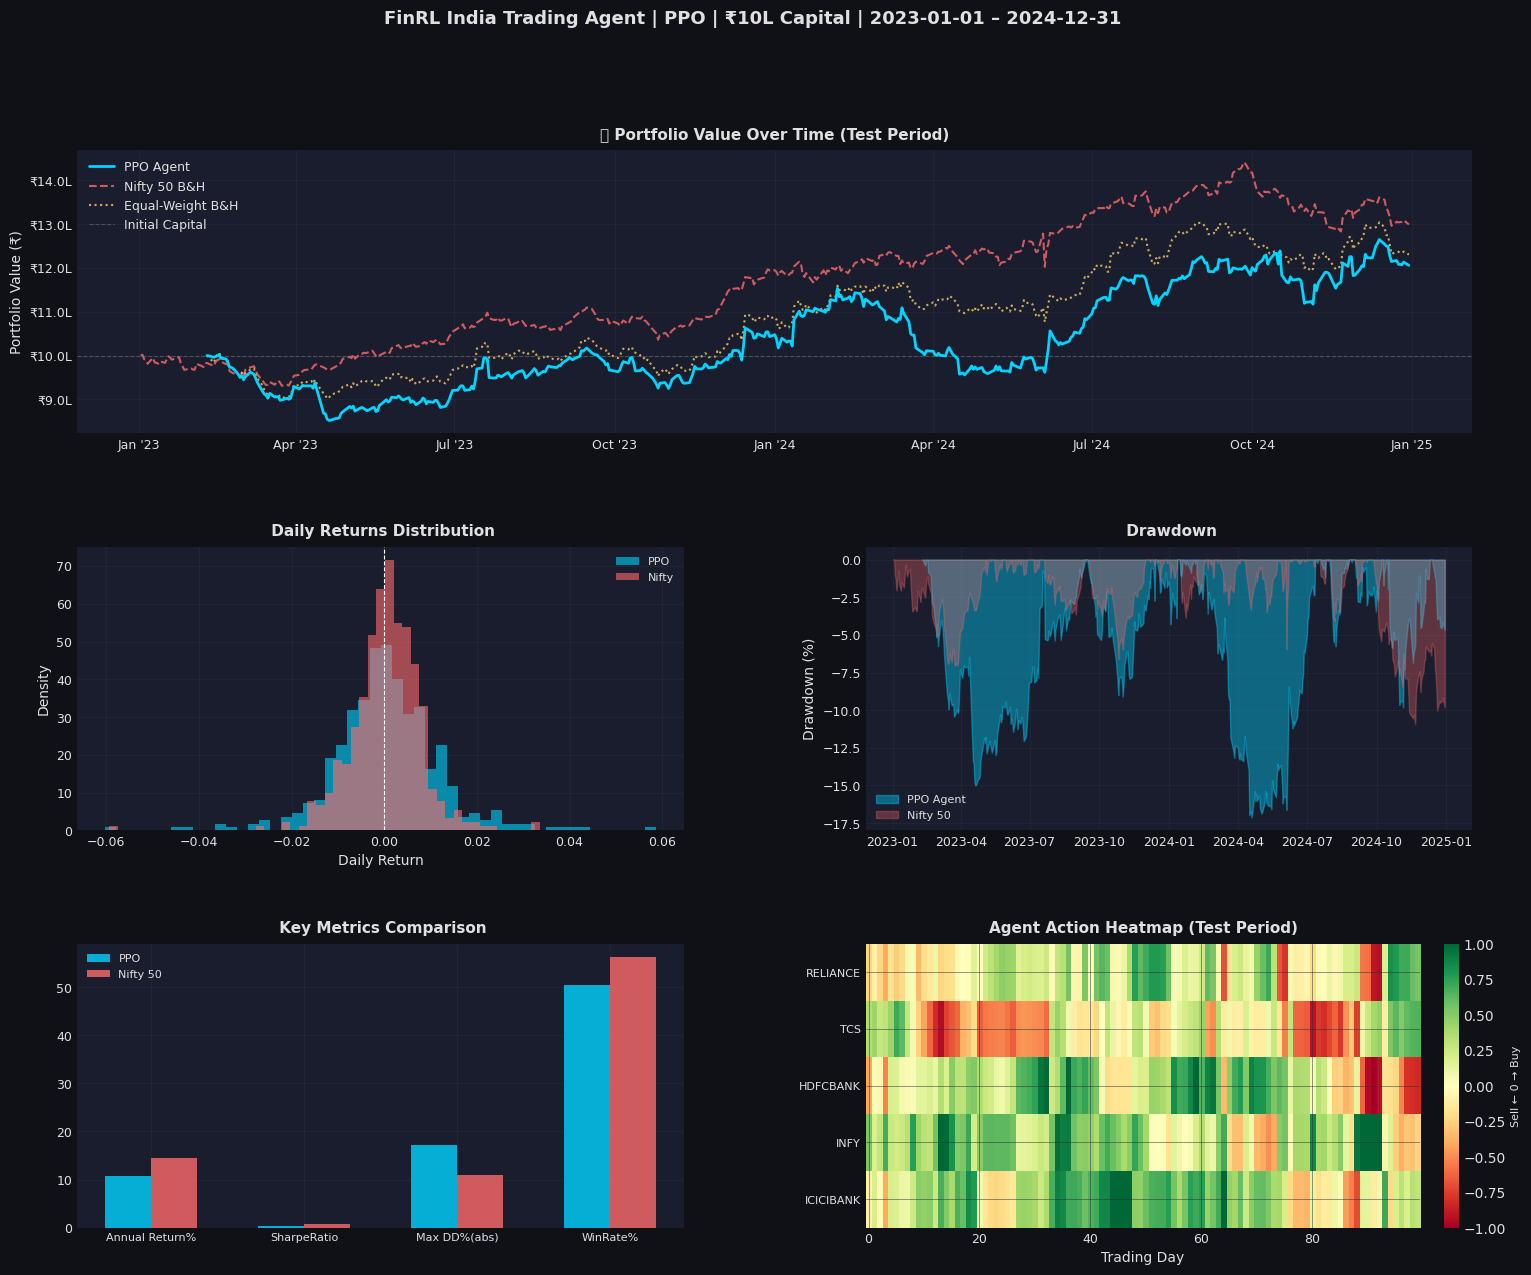

In [20]:
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("#0f1117")
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

COLORS = {
    "agent": "#00d4ff",
    "nifty": "#ff6b6b",
    "ewbh" : "#ffd166",
    "grid" : "#2a2d3a",
    "text" : "#e0e0e0",
    "bg"   : "#1a1d2e"
}

def style_ax(ax, title=""):
    ax.set_facecolor(COLORS["bg"])
    ax.tick_params(colors=COLORS["text"], labelsize=9)
    ax.xaxis.label.set_color(COLORS["text"])
    ax.yaxis.label.set_color(COLORS["text"])
    ax.title.set_color(COLORS["text"])
    ax.grid(True, color=COLORS["grid"], linewidth=0.5, alpha=0.7)
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS["grid"])
    if title:
        ax.set_title(title, fontsize=11, fontweight="bold", pad=8)

ax1 = fig.add_subplot(gs[0, :])
style_ax(ax1, "📈 Portfolio Value Over Time (Test Period)")

# Align dates
agent_dates = pd.to_datetime(agent_results["date"])
nifty_dates = pd.to_datetime(nifty["date"])
ewbh_dates  = pd.to_datetime(ewbh_prices["date"])

ax1.plot(agent_dates, agent_results["portfolio_value"],
         color=COLORS["agent"], lw=2, label=f"{ALGORITHM} Agent", zorder=5)
ax1.plot(nifty_dates, nifty["portfolio_value"],
         color=COLORS["nifty"], lw=1.5, ls="--", label="Nifty 50 B&H", alpha=0.8)
ax1.plot(ewbh_dates, ewbh_prices["portfolio_value"],
         color=COLORS["ewbh"], lw=1.5, ls=":", label="Equal-Weight B&H", alpha=0.8)
ax1.axhline(INITIAL_CAPITAL, color="gray", lw=0.8, ls="--", alpha=0.5, label="Initial Capital")

ax1.set_ylabel("Portfolio Value (₹)", color=COLORS["text"])
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1e5:.1f}L"))
ax1.legend(loc="upper left", facecolor=COLORS["bg"], edgecolor=COLORS["grid"],
           labelcolor=COLORS["text"], fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

ax2 = fig.add_subplot(gs[1, 0])
style_ax(ax2, " Daily Returns Distribution")
rets_agent = agent_results["portfolio_value"].pct_change().dropna()
rets_nifty = nifty["portfolio_value"].pct_change().dropna()
ax2.hist(rets_agent, bins=50, color=COLORS["agent"], alpha=0.6, label=ALGORITHM, density=True)
ax2.hist(rets_nifty, bins=50, color=COLORS["nifty"], alpha=0.6, label="Nifty", density=True)
ax2.axvline(0, color="white", lw=0.8, ls="--")
ax2.set_xlabel("Daily Return")
ax2.set_ylabel("Density")
ax2.legend(facecolor=COLORS["bg"], edgecolor=COLORS["grid"], labelcolor=COLORS["text"], fontsize=8)

ax3 = fig.add_subplot(gs[1, 1])
style_ax(ax3, " Drawdown")
pv_agent  = agent_results["portfolio_value"].values
roll_max  = pd.Series(pv_agent).cummax()
drawdown  = (pd.Series(pv_agent) - roll_max) / (roll_max + 1e-9) * 100
ax3.fill_between(agent_dates[:len(drawdown)], drawdown, 0,
                 color=COLORS["agent"], alpha=0.4, label=f"{ALGORITHM} Agent")
pv_nifty  = nifty["portfolio_value"].values
roll_n    = pd.Series(pv_nifty).cummax()
dd_nifty  = (pd.Series(pv_nifty) - roll_n) / (roll_n + 1e-9) * 100
ax3.fill_between(nifty_dates[:len(dd_nifty)], dd_nifty, 0,
                 color=COLORS["nifty"], alpha=0.3, label="Nifty 50")
ax3.set_ylabel("Drawdown (%)")
ax3.legend(facecolor=COLORS["bg"], edgecolor=COLORS["grid"], labelcolor=COLORS["text"], fontsize=8)

ax4 = fig.add_subplot(gs[2, 0])
style_ax(ax4, " Key Metrics Comparison")
metrics_names = ["Annual Return%", "SharpeRatio", "Max DD%(abs)", "WinRate%"]
agent_vals = [m_agent["annual_return"]*100, m_agent["sharpe"],
              abs(m_agent["max_drawdown"])*100, m_agent["win_rate"]*100]
nifty_vals = [m_nifty["annual_return"]*100,  m_nifty["sharpe"],
              abs(m_nifty["max_drawdown"])*100, m_nifty["win_rate"]*100]
x = np.arange(len(metrics_names))
w = 0.3
ax4.bar(x - w/2, agent_vals, w, color=COLORS["agent"], alpha=0.8, label=ALGORITHM)
ax4.bar(x + w/2, nifty_vals, w, color=COLORS["nifty"], alpha=0.8, label="Nifty 50")
ax4.set_xticks(x)
ax4.set_xticklabels(metrics_names, fontsize=8)
ax4.legend(facecolor=COLORS["bg"], edgecolor=COLORS["grid"], labelcolor=COLORS["text"], fontsize=8)

ax5 = fig.add_subplot(gs[2, 1])
style_ax(ax5, "Agent Action Heatmap (Test Period)")
if actions_log:
    action_arr = np.array(actions_log)  # shape: (days, n_stocks)
    n_show = min(len(action_arr), 100)
    im = ax5.imshow(action_arr[:n_show].T, aspect="auto",
                    cmap="RdYlGn", vmin=-1, vmax=1)
    ax5.set_yticks(range(len(TICKERS)))
    ax5.set_yticklabels([t.replace(".NS", "") for t in TICKERS], fontsize=8)
    ax5.set_xlabel("Trading Day", color=COLORS["text"])
    cbar = fig.colorbar(im, ax=ax5, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(colors=COLORS["text"])
    cbar.ax.set_ylabel("Sell ← 0 → Buy", color=COLORS["text"], fontsize=8)

fig.suptitle(
    f"FinRL India Trading Agent | {ALGORITHM} | ₹{INITIAL_CAPITAL/1e5:.0f}L Capital | {TEST_START} – {TEST_END}",
    color=COLORS["text"], fontsize=13, fontweight="bold", y=0.98
)
plt.savefig("results.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
